In [1]:
%load_ext autoreload
%autoreload 2

# Training as a function of the number of patterns

In [2]:
import torch
from wassa_functions import performance_as_a_function_of_dataset_parameters
from wassa_training import get_training_parameters
from wassa_plots import plot_results_std
import matplotlib.pyplot as plt
import numpy as np

In [3]:
date = '2025-10-15'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
device = 'cuda:1'

In [5]:
dataset_parameters = {
    'seed' : 91,
    
    'N_pre' : 300, # number of neurons
    'N_timesteps' : 251, # number of timesteps for the raster plot (in ms)
    'N_samples' : 100, # total number of samples in the dataset
    'N_sms' : 4, # number of structured spiking motifs

    'temporal_jitter' : 1, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'min_warping_coef' : 1, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_sms'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'proba_sms' : torch.ones(dataset_parameters['N_sms'])/dataset_parameters['N_sms']}) # probability of apparition of the different spiking motif

In [6]:
training_parameters_emd = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : True,
    'N_learnsteps' : 4000,
    'learning_rate' : .01,
    'penalty_type' : ['factors_cc'],
    'lambda' : [.01],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : None,
    'normalize_input' : True
}

In [7]:
training_parameters_mse = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 4000,
    'learning_rate' : .05,
    'penalty_type' : ['factors_cc'],
    'lambda' : [.01],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : None,
    'normalize_input' : True
}

In [8]:
dataset_variables = {
'N_sms' : torch.linspace(1,10,10).int().tolist(),
}

In [9]:
file_name = './results/results_patterns_last'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
training_metrics = ['training loss', 'testing loss', 'explained variance']
synthetic_metrics = ['kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings']
n_iter = 100
kfold = 1
do_seqnmf = False
results, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

RuntimeError: Parent directory ./results does not exist.

NameError: name 'results' is not defined

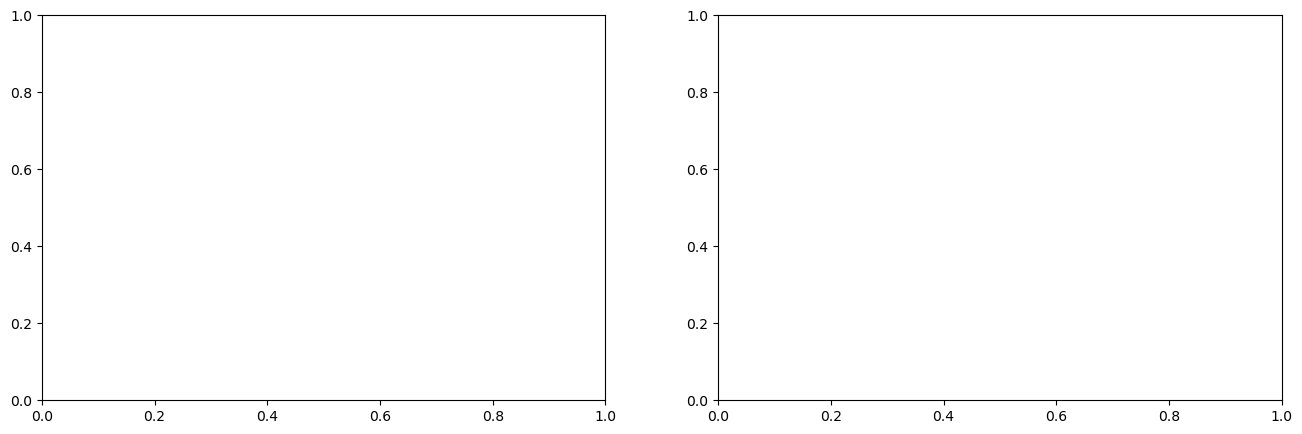

In [10]:
name_metrics = ['kernels similarity', 'mean timings similarity']
name_methods = ['MSE','EMD']
colors = ['darkolivegreen','blue','purple','orangered']
xlabel = '# patterns'
ymin = 0
quantile = True
fig, ax = plt.subplots(1,len(name_metrics), figsize=(16,5))
for i in range(len(name_metrics)):
    for m in range(len(name_methods)):
        if i==0:
            ylabel = 'similarity value'
            ymin, ymax = 0, 1
            do_legend, log_x, log_y = False, False, False
        elif i==2:
            ylabel = 'averaged timing difference'
            ymin, ymax = 0, None
            do_legend, log_x, log_y = False, False, False
        else:
            ylabel = None
            ymin, ymax = 0, 1
            do_legend, log_x, log_y = True, False, False
        ax[i] = plot_results_std(ax[i],results[:,m],dataset_variables['N_sms'],training_metrics+synthetic_metrics,xlabel,name_metrics[i],name_methods[m],colors[m],ymax=ymax,ymin=ymin,ylabel=ylabel,do_legend=do_legend,log_x=log_x,log_y=log_y,quantile=quantile)

In [11]:
from torch.distributions import Categorical
probs = torch.tensor([0.2, 0.5, 0.3]).unsqueeze(0).repeat(3,1)
print(probs)
print(Categorical(probs).sample())
categorical_dist = Categorical(probs)

# Take a sample
outcome = torch.zeros([3])
for i in range(1000):
    outcome[categorical_dist.sample().item()] += 1
print(outcome/1000)

tensor([[0.2000, 0.5000, 0.3000],
        [0.2000, 0.5000, 0.3000],
        [0.2000, 0.5000, 0.3000]])
tensor([1, 1, 2])


RuntimeError: a Tensor with 3 elements cannot be converted to Scalar

In [12]:
sample

NameError: name 'sample' is not defined